In [1]:
import pandas as pd
import numpy as np

In [2]:
# Read the CSV file - linked file  
file_path = "Merged_REDCap.xlsx" 
df = pd.read_excel(file_path)
df

,id,operation_date,redcap_event_name,postop_comp,ComplicationDate,los,readmission_30d,DischargeDate,dob,qol_date,...,a_e1,a_e2,a_e3,a_e4,a_e5,a_e6,a_e7,a_c6,a_c2,a_act11
0,1,NaT,baseline_arm_1,NaN,NaT,NaN,NaN,NaT,2049-08-04,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaT,5_years_postop_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,NaT,baseline_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2006-09-13,surgery_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,NaT,surgery_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17035,1770,NaT,preoperative_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17036,1770,NaT,baseline_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17037,1770,NaT,preoperative_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17038,1770,NaT,preoperative_arm_1,NaN,NaT,NaN,NaN,NaT,NaT,2025-02-24,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,3.0


In [3]:


# Calculate subscale scores
def calculate_subscale(df, cols, reverse_items=None):
    """Calculate subscale with 50% rule"""
    for col in cols:
        df[f"{col}_score"] = pd.to_numeric(df[col], errors='coerce')
        if reverse_items and col in reverse_items:
            df[f"{col}_score"] = 4 - df[f"{col}_score"]
    
    score_cols = [f"{col}_score" for col in cols]
    total_items = len(cols)
    min_items = total_items / 2
    num_answered = df[score_cols].notna().sum(axis=1)
    
    subscale_score = np.where(
        num_answered >= min_items,
        (df[score_cols].sum(axis=1, skipna=True) * total_items) / num_answered,
        np.nan
    )
    return subscale_score

# Define items
pwb_cols = [f"gp{i}" for i in range(1, 8)]
swb_cols = [f"gs{i}" for i in range(1, 8)]
ewb_cols = [f"ge{i}" for i in range(1, 7)]
fwb_cols = [f"gf{i}" for i in range(1, 8)]
ecs_cols = [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] + \
            [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]

pwb_reverse = pwb_cols
ewb_reverse = [f"ge{i}" for i in [1, 3, 4, 5, 6]]
ecs_reverse = ["a_e1", "a_e2", "a_e3", "a_e4", "a_e5", "a_e7", "a_act11", 
                "a_c2", "a_hn2", "a_hn3"]

# Calculate all subscales
df['pwb'] = calculate_subscale(df, pwb_cols, pwb_reverse)
df['swb'] = calculate_subscale(df, swb_cols, None)
df['ewb'] = calculate_subscale(df, ewb_cols, ewb_reverse)
df['fwb'] = calculate_subscale(df, fwb_cols, None)
df['ecs'] = calculate_subscale(df, ecs_cols, ecs_reverse)

# Calculate FACT-G (need all 4 subscales + 80% of 27 items)
fact_g_items = pwb_cols + swb_cols + ewb_cols + fwb_cols
fact_g_cols = [f"{col}_score" for col in fact_g_items]
fact_g_answered = df[fact_g_cols].notna().sum(axis=1)

df['fact_g'] = np.where(
    (df['pwb'].notna()) & (df['swb'].notna()) & (df['ewb'].notna()) & 
    (df['fwb'].notna()) & (fact_g_answered >= 22),
    df['pwb'] + df['swb'] + df['ewb'] + df['fwb'],
    np.nan
)

# Calculate FACT-E (need FACT-G + ECS + 80% of 44 items)
fact_e_items = fact_g_items + ecs_cols
fact_e_cols = [f"{col}_score" for col in fact_e_items]
fact_e_answered = df[fact_e_cols].notna().sum(axis=1)

df['fact_e'] = np.where(
    (df['fact_g'].notna()) & (df['ecs'].notna()) & (fact_e_answered >= 36),
    df['fact_g'] + df['ecs'],
    np.nan
)

print("Score calculation complete!")
print(f"FACT-E non-missing: {df['fact_e'].notna().sum()} / {len(df)}")


Score calculation complete!
FACT-E non-missing: 2527 / 17040


In [4]:
import pandas as pd
import numpy as np

# ===== BASELINE MISSINGNESS ANALYSIS BY YEAR =====

# Check ALL rows in df for dates (dates are NOT in baseline rows)
print(f"=== Getting dates from ALL events ===")
df['operation_date_temp'] = pd.to_datetime(df['operation_date'], errors='coerce')
df['DischargeDate_temp'] = pd.to_datetime(df['DischargeDate'], errors='coerce')
df['ComplicationDate_temp'] = pd.to_datetime(df['ComplicationDate'], errors='coerce')

print(f"Total rows in df: {len(df)}")
print(f"Non-null operation_date: {df['operation_date_temp'].notna().sum()}")
print(f"Non-null DischargeDate: {df['DischargeDate_temp'].notna().sum()}")
print(f"Non-null ComplicationDate: {df['ComplicationDate_temp'].notna().sum()}")

# Get reference date per patient from ALL rows
def get_patient_date(group):
    op_dates = group['operation_date_temp'].dropna()
    if len(op_dates) > 0:
        return op_dates.iloc[0]
    discharge_dates = group['DischargeDate_temp'].dropna()
    if len(discharge_dates) > 0:
        return discharge_dates.iloc[0]
    comp_dates = group['ComplicationDate_temp'].dropna()
    if len(comp_dates) > 0:
        return comp_dates.iloc[0]
    return pd.NaT

patient_dates = df.groupby('id').apply(get_patient_date).reset_index()
patient_dates.columns = ['id', 'ref_date']
print(f"Patients with valid dates: {patient_dates['ref_date'].notna().sum()} / {len(patient_dates)}")

# Check all scores for each patient at baseline
baseline_df = df[df['redcap_event_name'] == 'baseline_arm_1'].copy()
print(f"\nBaseline rows: {len(baseline_df)}, Unique patients: {baseline_df['id'].nunique()}")

score_cols = ['fact_e', 'pwb', 'swb', 'ewb', 'fwb', 'ecs']
baseline_scores = baseline_df.groupby('id')[score_cols].apply(lambda x: x.notna().any()).reset_index()
baseline_scores.columns = ['id'] + [f'has_{col}' for col in score_cols]

# Merge
analysis_df = patient_dates.merge(baseline_scores, on='id', how='inner')
print(f"Patients after merge: {len(analysis_df)}")

analysis_df = analysis_df[analysis_df['ref_date'].notna()].copy()
print(f"Patients with valid dates: {len(analysis_df)}")

if len(analysis_df) == 0:
    print("\n⚠️ No patients with both baseline data AND valid dates!")
else:
    analysis_df['year'] = analysis_df['ref_date'].dt.year
    
    # Count by year (cumulative) for all scores
    yearly_summary = []
    for year in sorted(analysis_df['year'].unique()):
        cumulative_data = analysis_df[analysis_df['year'] <= year]
        total = len(cumulative_data)
        
        result = {'year': year, 'cumulative_patients': total}
        
        # Calculate for each score
        for col in score_cols:
            with_score = cumulative_data[f'has_{col}'].sum()
            missing = total - with_score
            result[f'{col}_with_data'] = with_score
            result[f'{col}_missing'] = missing
            result[f'{col}_missing_rate'] = f"{(missing / total * 100):.1f}%"
        
        yearly_summary.append(result)
    
    summary_df = pd.DataFrame(yearly_summary)
    print("\n=== Baseline Missingness by Year (Cumulative) - All Scores ===")
    print(summary_df.to_string(index=False))

=== Getting dates from ALL events ===
Total rows in df: 17040
Non-null operation_date: 1283
Non-null DischargeDate: 378
Non-null ComplicationDate: 121


/tmp/ipykernel_2054555/2064650082.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  patient_dates = df.groupby('id').apply(get_patient_date).reset_index()


Patients with valid dates: 1222 / 1754

Baseline rows: 5071, Unique patients: 1754
Patients after merge: 1754
Patients with valid dates: 1222

=== Baseline Missingness by Year (Cumulative) - All Scores ===
 year  cumulative_patients  fact_e_with_data  fact_e_missing fact_e_missing_rate  pwb_with_data  pwb_missing pwb_missing_rate  swb_with_data  swb_missing swb_missing_rate  ewb_with_data  ewb_missing ewb_missing_rate  fwb_with_data  fwb_missing fwb_missing_rate  ecs_with_data  ecs_missing ecs_missing_rate
 2002                    1                 0               1              100.0%              0            1           100.0%              0            1           100.0%              0            1           100.0%              0            1           100.0%              0            1           100.0%
 2003                    2                 0               2              100.0%              0            2           100.0%              0            2           100.0%            

In [5]:
import pandas as pd
import numpy as np

# ===== BASELINE MISSINGNESS ANALYSIS BY YEAR =====

# Check ALL rows in df for dates (dates are NOT in baseline rows)
print(f"=== Getting dates from ALL events ===")
df['operation_date_temp'] = pd.to_datetime(df['operation_date'], errors='coerce')
df['DischargeDate_temp'] = pd.to_datetime(df['DischargeDate'], errors='coerce')
df['ComplicationDate_temp'] = pd.to_datetime(df['ComplicationDate'], errors='coerce')

print(f"Total rows in df: {len(df)}")
print(f"Non-null operation_date: {df['operation_date_temp'].notna().sum()}")
print(f"Non-null DischargeDate: {df['DischargeDate_temp'].notna().sum()}")
print(f"Non-null ComplicationDate: {df['ComplicationDate_temp'].notna().sum()}")

# Get reference date per patient from ALL rows
def get_patient_date(group):
    op_dates = group['operation_date_temp'].dropna()
    if len(op_dates) > 0:
        return op_dates.iloc[0]
    discharge_dates = group['DischargeDate_temp'].dropna()
    if len(discharge_dates) > 0:
        return discharge_dates.iloc[0]
    comp_dates = group['ComplicationDate_temp'].dropna()
    if len(comp_dates) > 0:
        return comp_dates.iloc[0]
    return pd.NaT

patient_dates = df.groupby('id').apply(get_patient_date).reset_index()
patient_dates.columns = ['id', 'ref_date']
print(f"Patients with valid dates: {patient_dates['ref_date'].notna().sum()} / {len(patient_dates)}")

# Check all scores for each patient at baseline
baseline_df = df[df['redcap_event_name'] == 'baseline_arm_1'].copy()
print(f"\nBaseline rows: {len(baseline_df)}, Unique patients: {baseline_df['id'].nunique()}")

score_cols = ['fact_e', 'pwb', 'swb', 'ewb', 'fwb', 'ecs']

# Define all timepoints
timepoints = ['baseline_arm_1', 'preoperative_arm_1', 'surgery_arm_1', '1_month_postop_arm_1', 
              '3_months_postop_arm_1', '6_months_postop_arm_1', '1_year_postop_arm_1',
              '2_years_postop_arm_1', '3_years_postop_arm_1',
              '4_years_postop_arm_1', '5_years_postop_arm_1']

# Process each timepoint
for timepoint in timepoints:
    print(f"\n{'='*60}")
    print(f"Processing: {timepoint}")
    print('='*60)
    
    timepoint_df = df[df['redcap_event_name'] == timepoint].copy()
    print(f"Rows: {len(timepoint_df)}, Unique patients: {timepoint_df['id'].nunique()}")
    
    timepoint_scores = timepoint_df.groupby('id')[score_cols].apply(lambda x: x.notna().any()).reset_index()
    timepoint_scores.columns = ['id'] + [f'has_{col}' for col in score_cols]
    
    # Merge
    analysis_df = patient_dates.merge(timepoint_scores, on='id', how='inner')
    print(f"Patients after merge: {len(analysis_df)}")
    
    analysis_df = analysis_df[analysis_df['ref_date'].notna()].copy()
    print(f"Patients with valid dates: {len(analysis_df)}")
    
    if len(analysis_df) == 0:
        print(f"⚠️ No patients with {timepoint} data AND valid dates!")
        continue
    
    analysis_df['year'] = analysis_df['ref_date'].dt.year
    
    # Count by year (cumulative) for all scores
    yearly_summary = []
    for year in sorted(analysis_df['year'].unique()):
        cumulative_data = analysis_df[analysis_df['year'] <= year]
        total = len(cumulative_data)
        
        result = {'year': year, 'cumulative_patients': total}
        
        # Calculate for each score
        for col in score_cols:
            with_score = cumulative_data[f'has_{col}'].sum()
            missing = total - with_score
            result[f'{col}_with_data'] = with_score
            result[f'{col}_missing'] = missing
            result[f'{col}_missing_rate'] = f"{(missing / total * 100):.1f}%"
        
        yearly_summary.append(result)
    
    summary_df = pd.DataFrame(yearly_summary)
    print(f"\n=== {timepoint} Missingness by Year (Cumulative) ===")
    print(summary_df.to_string(index=False))

=== Getting dates from ALL events ===
Total rows in df: 17040
Non-null operation_date: 1283
Non-null DischargeDate: 378
Non-null ComplicationDate: 121


/tmp/ipykernel_2054555/3522182107.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  patient_dates = df.groupby('id').apply(get_patient_date).reset_index()


Patients with valid dates: 1222 / 1754

Baseline rows: 5071, Unique patients: 1754

Processing: baseline_arm_1
Rows: 5071, Unique patients: 1754
Patients after merge: 1754
Patients with valid dates: 1222

=== baseline_arm_1 Missingness by Year (Cumulative) ===
 year  cumulative_patients  fact_e_with_data  fact_e_missing fact_e_missing_rate  pwb_with_data  pwb_missing pwb_missing_rate  swb_with_data  swb_missing swb_missing_rate  ewb_with_data  ewb_missing ewb_missing_rate  fwb_with_data  fwb_missing fwb_missing_rate  ecs_with_data  ecs_missing ecs_missing_rate
 2002                    1                 0               1              100.0%              0            1           100.0%              0            1           100.0%              0            1           100.0%              0            1           100.0%              0            1           100.0%
 2003                    2                 0               2              100.0%              0            2           100.0%  

                              ge1         ge2         ge3         ge4  \
1_month_postop_arm_1    44.060150   43.909774   45.112782   44.360902   
1_year_postop_arm_1      5.820106    5.820106    6.878307    5.291005   
2_years_postop_arm_1     3.921569    3.921569    3.921569    3.921569   
3_months_postop_arm_1    2.702703    4.729730    4.054054    3.378378   
3_years_postop_arm_1     6.410256    8.974359    7.692308    6.410256   
4_years_postop_arm_1     4.347826    6.521739    4.347826    4.347826   
5_years_postop_arm_1    94.918567   94.983713   94.918567   94.918567   
6_months_postop_arm_1    3.174603    3.703704    3.703704    4.232804   
baseline_arm_1          47.491448   48.916762   50.969213   48.289624   
preoperative_arm_1      74.343832   74.409449   74.540682   74.278215   
surgery_arm_1          100.000000  100.000000  100.000000  100.000000   

                              ge5         ge6  
1_month_postop_arm_1    44.210526   44.060150  
1_year_postop_arm_1      5.

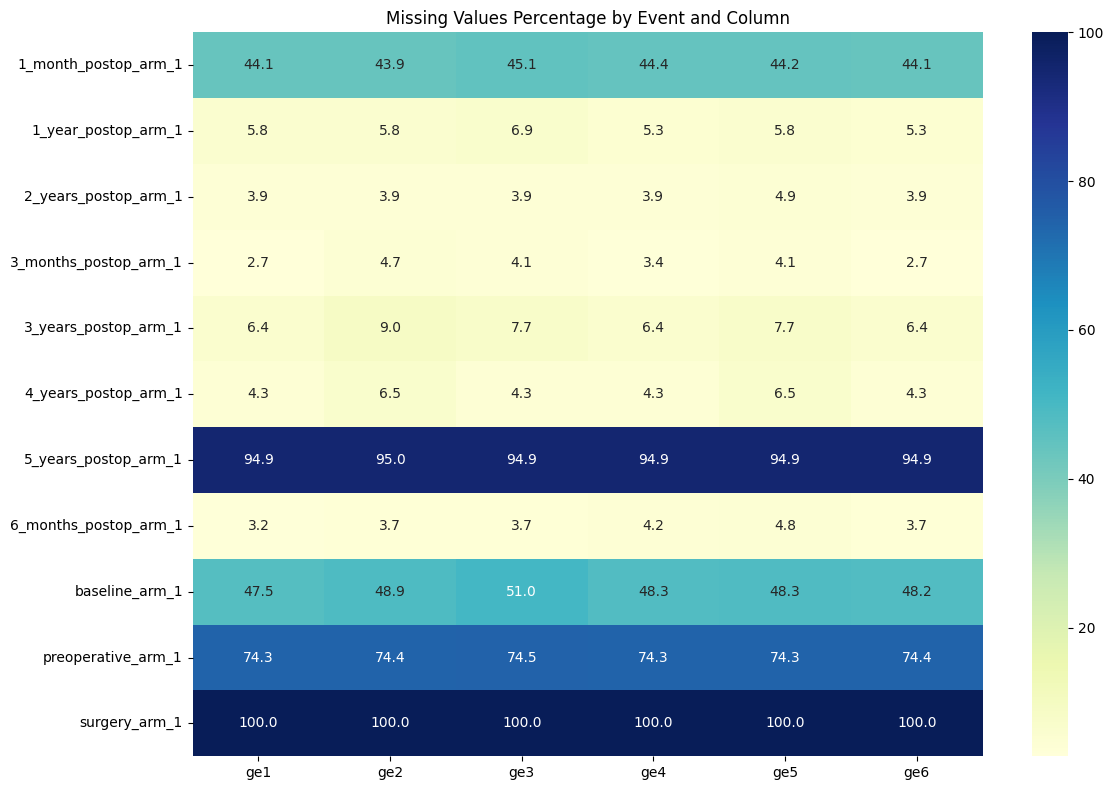

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# First, let's create a function to calculate missing value percentages
def calculate_missing_percentages(df, columns, group_col):
    # Group by both id and the specified column to handle multiple rows per (id, group_col)
    grouped = df.groupby(['id', group_col])
    
    # Aggregate by taking the first non-null value for each (id, group_col) combination
    aggregated_df = grouped[columns].apply(lambda x: x.bfill().ffill().iloc[0] if len(x) > 0 else pd.Series([None] * len(columns), index=columns))
    aggregated_df = aggregated_df.reset_index()
    
    # Now group by the specified column only
    grouped_by_event = aggregated_df.groupby(group_col)
    
    # Initialize a dictionary to store results
    missing_percentages = {}
    
    # Calculate missing percentages for each group
    for name, group in grouped_by_event:
        # Calculate percentage of missing values for each column
        missing_pct = group[columns].isna().mean() * 100
        missing_percentages[name] = missing_pct
    
    # Convert to DataFrame for better visualization
    result_df = pd.DataFrame(missing_percentages)
    return result_df.T # Transpose for better readability

# Columns of interest
ge_columns = ['ge1', 'ge2', 'ge3', 'ge4', 'ge5', 'ge6']

# Calculate missing percentages for each redcap_event_name
missing_pct_by_event = calculate_missing_percentages(df, ge_columns, 'redcap_event_name')

# Display the results
print(missing_pct_by_event)

plt.figure(figsize=(12, 8))
sns.heatmap(missing_pct_by_event, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Missing Values Percentage by Event and Column')
plt.tight_layout()
plt.show()